## Polynomial Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [3]:
# 1. Fake Data banate hain (Speed vs Fuel Efficiency)
X = np.array([10, 20, 40, 60, 80, 100, 120, 140]).reshape(-1, 1)
y = np.array([5,  8,  12, 15, 14, 11,  7,  4])

In [4]:
# 2. Ordinary Seedhi Lakeer (Linear Regression)
linear_model = LinearRegression()
linear_model.fit(X, y)
linear_pred = linear_model.predict(X)

In [5]:
# 3. POLYNOMIAL MAGIC: Data ko X^2 mein convert karte hain (Degree=2)
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_transformer.fit_transform(X)

In [6]:
# 4. Transformed data par LinearRegression chalana
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


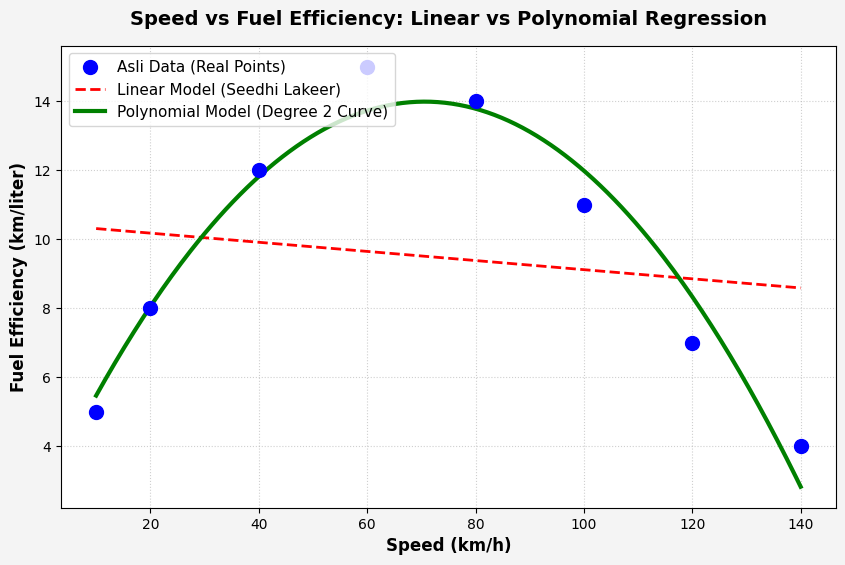

In [7]:
# Curve ko smooth karne ke liye hum 10 se 140 tak bohot saare barik points banate hain
X_smooth = np.linspace(10, 140, 300).reshape(-1, 1)
X_smooth_poly = poly_transformer.transform(X_smooth) # Unhein bhi polynomial mein badlein
poly_pred_smooth = poly_model.predict(X_smooth_poly)  # Smooth curve ki predictions

# 1. Figure ka size aur design set karein
plt.figure(figsize=(10, 6), facecolor='#f4f4f4')
ax = plt.axes()
ax.set_facecolor("#ffffff")

# 2. Asli Data points ko plot karein (As blue dots)
plt.scatter(X, y, color='blue', s=100, label='Asli Data (Real Points)', zorder=3)

# 3. Linear Regression ki nakaam seedhi lakeer (As red dashed line)
plt.plot(X, linear_pred, color='red', linestyle='--', linewidth=2, label='Linear Model (Seedhi Lakeer)')

# 4. Polynomial Regression ka khoobsurat curve (As green solid line)
plt.plot(X_smooth, poly_pred_smooth, color='green', linewidth=3, label='Polynomial Model (Degree 2 Curve)')

# 5. Graph ki khoobsurti (Labels, Title, Grid)
plt.title('Speed vs Fuel Efficiency: Linear vs Polynomial Regression', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Speed (km/h)', fontsize=12, fontweight='bold')
plt.ylabel('Fuel Efficiency (km/liter)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# 6. Graph ko screen par dikhana
plt.show()

In [8]:
# 5. Hasil (Results) check karte hain
print("--- Weights Comparison ---")
print(f"Linear Model Weight: {linear_model.coef_[0]:.4f}")
print(f"Polynomial Model Weights (w1, w2): {poly_model.coef_}")
print(f"Polynomial Model Bias (b): {poly_model.intercept_:.4f}")

--- Weights Comparison ---
Linear Model Weight: -0.0132
Polynomial Model Weights (w1, w2): [ 0.32738095 -0.00231793]
Polynomial Model Bias (b): 2.4286
